# Red neuronal convolucional sobre texto (TextCNN) para clasificación multi-etiqueta (Synapse)

**Materia:** Simulación

**Autores:** Carlos Alberto Canabal Cordero y Sebastian Jose Leal Florez

**Objetivo:** Entrenar de extremo a extremo un modelo **TextCNN** multiclase con **cuatro cabezas de salida** (nivel técnico, urgencia, emoción y dominio del mensaje), a partir de un corpus en JSON y embeddings iniciales en español (**FastText** en formato `.vec`).

El cuaderno documenta el flujo experimental de forma secuencial: preparación del entorno, verificación de datos y vectores, construcción del vocabulario, entrenamiento con criterios de parada y registro de métricas, y visualización del historial. En Google Colab, si no se detecta un fichero de vectores válido, puede descargarse automáticamente la distribución oficial comprimida.

En el **repositorio Git** el material vive bajo `neural_network/` (`notebook/` con este `.ipynb` y `scripts/`). En **Google Colab** el explorador de archivos muestra sobre todo el almacenamiento de la sesión (`/content`): allí debe replicarse solo lo que el runtime necesita (`scripts/` y `data/`).

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Organizar el entorno

En Colab el panel **Archivos** refleja el almacenamiento temporal (habitualmente `/content`).

**Colab:** en `/content` debe existir `scripts/` (`build_vocab.py`, `train_textcnn.py`, `textcnn_model.py`, `training_labels.py` y `export_onnx.py`) y `data/` con `train.json`, `val.json` y `test.json`. Tras `%cd /content`, la primera celda de código detecta `scripts/build_vocab.py` y fija rutas coherentes. Los artefactos se escriben en `/content/artifacts` y `/content/checkpoints`. El fichero FastText puede colocarse en `/content` o descargarse en Colab según la sección 2.

**Repositorio Git:** la misma lógica de `scripts/` + `data/` puede vivir como `neural_network/scripts/` y `neural_network/notebook/data/`; si los JSON están solo en `notebook/data/`, el cuaderno usará esas rutas. La variable de entorno `SYNAPSE_NOTEBOOK_ROOT` fuerza la raíz si hace falta.

```
# Colab (sesión /content)
/content/
├── scripts/          # mismos .py que en el repo
├── data/
│   ├── train.json
│   ├── val.json
│   └── test.json
├── artifacts/        # generado al ejecutar
└── checkpoints/      # generado al ejecutar
```


In [10]:
import os
from pathlib import Path

_cwd = Path.cwd()
if os.environ.get("SYNAPSE_NOTEBOOK_ROOT"):
    ROOT = Path(os.environ["SYNAPSE_NOTEBOOK_ROOT"]).resolve()
elif (_cwd / "scripts" / "build_vocab.py").is_file():
    ROOT = _cwd.resolve()
elif (_cwd.parent / "scripts" / "build_vocab.py").is_file():
    ROOT = _cwd.parent.resolve()
else:
    ROOT = Path("/content").resolve()

os.chdir(ROOT)
print("ROOT =", ROOT)

for rel in ("scripts/build_vocab.py", "scripts/train_textcnn.py", "scripts/textcnn_model.py", "scripts/training_labels.py"):
    p = ROOT / rel
    if not p.is_file():
        raise FileNotFoundError(
            f"No se encuentra {rel} bajo {ROOT}. Colab: suba scripts/ a /content (junto a data/). "
            "Repo: %cd a la carpeta que contiene scripts/ (p. ej. neural_network/). "
            "Opcional: export SYNAPSE_NOTEBOOK_ROOT=/ruta/absoluta"
        )

PROJECT_ROOT = ROOT.parent if (ROOT.parent / "dataset").is_dir() else ROOT

if os.environ.get("SYNAPSE_DATA_DIR"):
    DATA_DIR = Path(os.environ["SYNAPSE_DATA_DIR"]).resolve()
    ART_DIR = DATA_DIR / "artifacts"
    CKPT_DIR = DATA_DIR / "checkpoints"
elif (PROJECT_ROOT / "dataset" / "final" / "train.json").is_file():
    DATA_DIR = PROJECT_ROOT / "dataset" / "final"
    ART_DIR = DATA_DIR / "artifacts"
    CKPT_DIR = DATA_DIR / "checkpoints"
elif (ROOT / "data" / "train.json").is_file():
    DATA_DIR = ROOT / "data"
    ART_DIR = ROOT / "artifacts"
    CKPT_DIR = ROOT / "checkpoints"
elif (ROOT / "notebook" / "data" / "train.json").is_file():
    DATA_DIR = ROOT / "notebook" / "data"
    ART_DIR = ROOT / "notebook" / "artifacts"
    CKPT_DIR = ROOT / "notebook" / "checkpoints"
else:
    DATA_DIR = ROOT / "data"
    ART_DIR = ROOT / "artifacts"
    CKPT_DIR = ROOT / "checkpoints"

DATA_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)
VEC_DIR = DATA_DIR.parent
print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_DIR =", DATA_DIR)
print("ART_DIR =", ART_DIR)
print("CKPT_DIR =", CKPT_DIR)
print("VEC_DIR =", VEC_DIR)


import subprocess


def _run_subprocess_streaming(cmd, cwd):
    """Ejecuta un comando hijo mostrando salida línea a línea (Jupyter/Colab)."""
    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"
    proc = subprocess.Popen(
        cmd,
        cwd=cwd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )
    if proc.stdout is None:
        rc = proc.wait()
        raise RuntimeError(f"Popen sin stdout (código {rc})")
    for line in proc.stdout:
        print(line, end="", flush=True)
    proc.wait()
    if proc.returncode != 0:
        raise subprocess.CalledProcessError(proc.returncode, cmd)


ROOT = /content
PROJECT_ROOT = /content
DATA_DIR = /content/data
ART_DIR = /content/artifacts
CKPT_DIR = /content/checkpoints
VEC_DIR = /content


## 1. Configuración del entorno

Se instalan las dependencias necesarias para **PyTorch**, métricas (**scikit-learn**) y visualización (**matplotlib**).


In [11]:
%pip install -q torch scikit-learn numpy matplotlib


In [12]:
import sys
import torch

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: no disponible (entrenamiento en CPU; más lento)")


Python: 3.12.13
PyTorch: 2.10.0+cu128
GPU: Tesla T4


## 2. Rutas a datos y a FastText

Los JSON del split se leen desde `DATA_DIR` (definido en la celda anterior: típicamente `/content/data` en Colab o `neural_network/notebook/data` en el clon del repo). Cada registro debe incluir el texto (`texto` o `text`, o `title`/`body`) y las etiquetas según `scripts/training_labels.py`.

El vector FastText se busca en `SYNAPSE_FASTTEXT_VEC`, luego `VEC_DIR/cc.es.300.vec`, `ROOT/cc.es.300.vec` y `/content/cc.es.300.vec`. En Colab, si no hay ninguno, la siguiente celda descarga el `.vec.gz` oficial y descomprime bajo `VEC_DIR/cc.es.300.vec` (en el layout plano, `VEC_DIR` coincide con `ROOT` = `/content`).


In [13]:
import gzip
import os
import shutil
import urllib.request
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

_candidates = []
if os.environ.get("SYNAPSE_FASTTEXT_VEC"):
    _candidates.append(Path(os.environ["SYNAPSE_FASTTEXT_VEC"]).resolve())
_candidates.append((VEC_DIR / "cc.es.300.vec").resolve())
_candidates.append((ROOT / "cc.es.300.vec").resolve())
_candidates.append(Path("/content/cc.es.300.vec").resolve())

FASTTEXT_VEC = next((p for p in _candidates if p.is_file()), None)

if FASTTEXT_VEC is None:
    dest = (VEC_DIR / "cc.es.300.vec").resolve()
    if IN_COLAB:
        url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz"
        gz_path = VEC_DIR / "cc.es.300.vec.gz"
        print("No se encontró cc.es.300.vec; descarga automática en Colab (oficial FastText, español 300d).")
        print("Origen:", url)
        print("Aviso: el .vec descomprimido ocupa varios GB; la descarga y la descompresión pueden tardar.")
        urllib.request.urlretrieve(url, str(gz_path))
        print("Descomprimiendo hacia", dest, "...")
        with gzip.open(gz_path, "rb") as src, open(dest, "wb") as dst:
            shutil.copyfileobj(src, dst, length=1024 * 1024 * 16)
        gz_path.unlink(missing_ok=True)
        FASTTEXT_VEC = dest
        print("Listo:", FASTTEXT_VEC)
    else:
        raise FileNotFoundError(
            "No hay fichero FastText .vec. Colóquelo en ROOT o en VEC_DIR, defina SYNAPSE_FASTTEXT_VEC, "
            "o ejecute en Google Colab para descarga automática."
        )
else:
    print("FastText encontrado:", FASTTEXT_VEC)

train_p = DATA_DIR / "train.json"
val_p = DATA_DIR / "val.json"
test_p = DATA_DIR / "test.json"

for label, p in [("train", train_p), ("val", val_p), ("test", test_p)]:
    if not p.is_file():
        raise FileNotFoundError(
            f"Falta {p}. Suba train/val/test a DATA_DIR ({DATA_DIR}) o ajuste ROOT / SYNAPSE_NOTEBOOK_ROOT."
        )

print("train:", train_p, "→", train_p.stat().st_size // 1024, "KiB")
print("val:", val_p)
print("test:", test_p)
print("FastText:", FASTTEXT_VEC, "→", FASTTEXT_VEC.stat().st_size // (1024 * 1024), "MiB (aprox.)")

# Validación rápida del split contra la taxonomía cargada en scripts/training_labels.py.
import json
import sys

sys.path.insert(0, str(ROOT / "scripts"))
from training_labels import LABEL_SPECS

for split_name, split_path in (("train", train_p), ("val", val_p), ("test", test_p)):
    rows = json.load(open(split_path, encoding="utf-8"))
    if not rows:
        raise ValueError(f"{split_path} está vacío")
    for head, allowed in LABEL_SPECS.items():
        allowed_set = set(allowed)
        bad = sorted({str(r.get(head)) for r in rows if r.get("supervision", {}).get(head, True) and r.get(head) not in allowed_set})
        if bad:
            raise ValueError(f"{split_name}: etiquetas fuera de taxonomía en {head}: {bad[:10]}")
    print(f"{split_name}: {len(rows)} filas validadas")

quality_report_path = DATA_DIR / "quality_report.json"
if quality_report_path.is_file():
    q = json.load(open(quality_report_path, encoding="utf-8"))
    print("quality_report gates all_pass =", q.get("gates", {}).get("all_pass"))


FastText encontrado: /content/cc.es.300.vec
train: /content/data/train.json → 11139 KiB
val: /content/data/val.json
test: /content/data/test.json
FastText: /content/cc.es.300.vec → 4309 MiB (aprox.)
train: 8400 filas validadas
val: 1800 filas validadas
test: 1800 filas validadas


## 3. Marco teórico

La arquitectura TextCNN, en la línea de Kim (2014), representa cada documento como una secuencia de índices léxicos sobre los que actúan convoluciones unidimensionales con distintas anchuras de ventana; el max-pooling global reduce cada mapa a un escalar y la concatenación de dichos escalares produce un vector de contexto de dimensión fija alimentar las capas densas.

En este experimento el encabezado del clasificador se divide en cuatro salidas softmax independientes (multitarea con una etiqueta por dimensión). La función de pérdida optimizada es la suma de cuatro entropías cruzadas, de modo que el gradiente refleja simultáneamente el error en nivel técnico, urgencia, emoción y dominio.

La matriz de embeddings se inicializa alineando cada token del vocabulario inferido del conjunto de entrenamiento con su fila correspondiente en el recurso FastText cuando existe; las entradas sin vector preentrenado reciben inicialización gaussiana acotada con semilla fija, según la implementación de `build_vocab.py`. La regularización combina dropout, decaimiento de pesos con AdamW, recorte de norma del gradiente y un periodo inicial de congelación de embeddings cuya duración controla `train_textcnn.py`.


## 4. Construcción de vocabulario e incrustaciones

Se calculan frecuencias de tokens sobre `data/train.json`, se filtra por frecuencia mínima y tamaño máximo de vocabulario, y se generan `artifacts/vocab.json` y `artifacts/embedding_init.pt`. La lectura del `.vec` es **por flujo** (no se carga el léxico completo de FastText en memoria).


In [14]:
import sys

cmd_vocab = [
    sys.executable,
    str(ROOT / "scripts" / "build_vocab.py"),
    "--train",
    str(DATA_DIR / "train.json"),
    "--fasttext",
    str(FASTTEXT_VEC),
    "--min-freq",
    "2",
    "--max-vocab",
    "40000",
    "--out-dir",
    str(ART_DIR),
    "--seed",
    "42",
]
_run_subprocess_streaming(cmd_vocab, ROOT)
print("Vocabulario e incrustaciones listos en", ART_DIR)

Leyendo FastText (streaming) /content/cc.es.300.vec ...
Vocab tokens (sin pad/unk): 26018, con vector FastText en fichero: 14365, dim=300
Escrito /content/artifacts/vocab.json y embedding_init.pt
Vocabulario e incrustaciones listos en /content/artifacts


## 5. Compilación y entrenamiento

El optimizador es **AdamW**. El criterio de guardado del mejor estado es la **media macro-F1 en validación** (`f1_macro_mean`). La **parada temprana** se activa cuando dicha métrica deja de mejorar durante `patience` épocas consecutivas.

Al finalizar el bucle se recalculan métricas en validación y test; se escriben `run_config.json`, `history.json`, `dod_report.json`, `test_metrics.json`, entre otros, junto a `best.pt`.


In [15]:
import sys

OUT = CKPT_DIR / "textcnn_run"

cmd_train = [
    sys.executable,
    str(ROOT / "scripts" / "train_textcnn.py"),
    "--train",
    str(DATA_DIR / "train.json"),
    "--val",
    str(DATA_DIR / "val.json"),
    "--test",
    str(DATA_DIR / "test.json"),
    "--vocab",
    str(ART_DIR / "vocab.json"),
    "--embedding",
    str(ART_DIR / "embedding_init.pt"),
    "--out-dir",
    str(OUT),
    "--max-len",
    "160",
    "--epochs",
    "80",
    "--batch-size",
    "32",
    "--lr",
    "1e-3",
    "--weight-decay",
    "0.03",
    "--dropout",
    "0.55",
    "--freeze-epochs",
    "3",
    "--patience",
    "8",
    "--early-stop-metric",
    "mixed_f1_macro_mean",
    "--seed",
    "42",
]
_run_subprocess_streaming(cmd_train, ROOT)
print("Checkpoint en", OUT)


Parámetros entrenables (inicial): 443267
Epoch 1: train_loss=5.1855 train_acc=0.6953 val_loss=3.6804 val_acc=0.6748 f1_macro_mean(val)=0.6625 val_real_f1=0.2564 best_metric=0.6625 val:nivel_tecnico=0.825 val:urgencia=0.881 val:emocion=0.349 val:dominio=0.595
Epoch 2: train_loss=3.3167 train_acc=0.8384 val_loss=2.4178 val_acc=0.8025 f1_macro_mean(val)=0.8176 val_real_f1=0.2769 best_metric=0.8176 val:nivel_tecnico=0.842 val:urgencia=0.890 val:emocion=0.691 val:dominio=0.847
Epoch 3: train_loss=2.3563 train_acc=0.8602 val_loss=1.8933 val_acc=0.8228 f1_macro_mean(val)=0.8432 val_real_f1=0.3197 best_metric=0.8432 val:nivel_tecnico=0.849 val:urgencia=0.898 val:emocion=0.765 val:dominio=0.861
Epoch 4: embeddings descongelados, lr -> 0.0005
Epoch 4: train_loss=1.8295 train_acc=0.8892 val_loss=1.6968 val_acc=0.8401 f1_macro_mean(val)=0.8574 val_real_f1=0.3504 best_metric=0.8574 val:nivel_tecnico=0.872 val:urgencia=0.909 val:emocion=0.771 val:dominio=0.877
Epoch 5: train_loss=1.5158 train_acc=0.

In [19]:
# Post-procesamiento sin reentrenar: TTA + calibración de sesgos por clase.
# Usa el checkpoint ya entrenado y ajusta solo logits en validación.

cmd_calib = [
    sys.executable,
    str(ROOT / "scripts" / "calibrate_checkpoint.py"),
    "--checkpoint",
    str(CKPT_DIR / "textcnn_run" / "best.pt"),
    "--val",
    str(DATA_DIR / "val.json"),
    "--test",
    str(DATA_DIR / "test.json"),
    "--out-json",
    str(CKPT_DIR / "textcnn_run" / "posthoc_calibration.json"),
    "--views",
    "score",
    "--batch-size",
    "64",
]
_run_subprocess_streaming(cmd_calib, ROOT)
print("Calibración post-hoc en", CKPT_DIR / "textcnn_run" / "posthoc_calibration.json")


{
  "views": "score",
  "checkpoint_epoch": 10,
  "baseline_val": {
    "f1_macro_nivel_tecnico": 0.8987732274575709,
    "f1_macro_urgencia": 0.9005124266927783,
    "f1_macro_emocion": 0.7971964619334563,
    "f1_macro_dominio": 0.9013017331797141,
    "f1_macro_mean": 0.8744459623158799
  },
  "calibrated_val": {
    "f1_macro_nivel_tecnico": 0.9024539934630949,
    "f1_macro_urgencia": 0.9117186422650568,
    "f1_macro_emocion": 0.8194122726625946,
    "f1_macro_dominio": 0.9116861616136682,
    "f1_macro_mean": 0.8863177675011036
  },
  "baseline_test": {
    "f1_macro_nivel_tecnico": 0.8818554949355256,
    "f1_macro_urgencia": 0.8965541276536015,
    "f1_macro_emocion": 0.7848856347297927,
    "f1_macro_dominio": 0.8853948576116872,
    "f1_macro_mean": 0.8621725287326518
  },
  "calibrated_test": {
    "f1_macro_nivel_tecnico": 0.8859359451897127,
    "f1_macro_urgencia": 0.9011228325347013,
    "f1_macro_emocion": 0.7967006971519142,
    "f1_macro_dominio": 0.8901466106850164,

## 6. Curvas de aprendizaje

A partir de `history.json` se representan la pérdida de entrenamiento y validación y la evolución de la **macro-F1 media** en validación (agregado sobre las cuatro cabezas).


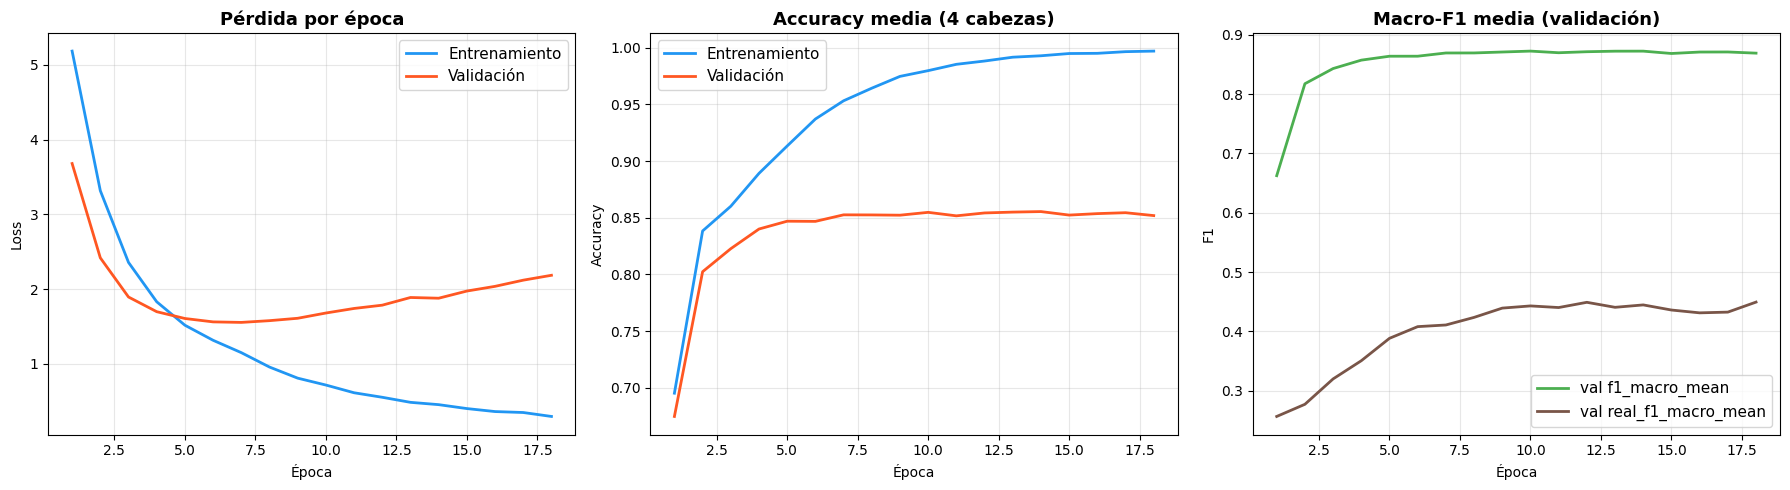

In [21]:
import json

import matplotlib.pyplot as plt

hist_path = CKPT_DIR / "textcnn_run" / "history.json"
with open(hist_path, encoding="utf-8") as f:
    history = json.load(f)

epochs = [h["epoch"] for h in history]
train_loss = [h["train_loss"] for h in history]
val_loss = [h["val_loss"] for h in history]
_HEADS = ("nivel_tecnico", "urgencia", "emocion", "dominio")


def _mean_head_acc(metrics):
    return sum(metrics[f"acc_{k}"] for k in _HEADS) / len(_HEADS)


train_acc = [_mean_head_acc(h["metrics_train"]) for h in history]
val_acc = [_mean_head_acc(h["metrics_val"]) for h in history]
val_f1 = [h["metrics_val"]["f1_macro_mean"] for h in history]
val_real_f1 = []
for h in history:
    real_metrics = h.get("metrics_val_by_source", {}).get("__real__", {}).get("metrics", {})
    val_real_f1.append(real_metrics.get("f1_macro_mean"))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(epochs, train_loss, label="Entrenamiento", linewidth=2, color="#2196F3")
ax1.plot(epochs, val_loss, label="Validación", linewidth=2, color="#FF5722")
ax1.set_title("Pérdida por época", fontsize=13, fontweight="bold")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_acc, label="Entrenamiento", linewidth=2, color="#2196F3")
ax2.plot(epochs, val_acc, label="Validación", linewidth=2, color="#FF5722")
ax2.set_title("Accuracy media (4 cabezas)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Época")
ax2.set_ylabel("Accuracy")
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

ax3.plot(epochs, val_f1, label="val f1_macro_mean", linewidth=2, color="#4CAF50")
if any(v is not None for v in val_real_f1):
    ax3.plot(epochs, val_real_f1, label="val real_f1_macro_mean", linewidth=2, color="#795548")
ax3.set_title("Macro-F1 media (validación)", fontsize=13, fontweight="bold")
ax3.set_xlabel("Época")
ax3.set_ylabel("F1")
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Salidas generadas y persistencia

Los directorios concretos dependen de la celda inicial (`ART_DIR`, `CKPT_DIR`). En Colab suelen ser `/content/artifacts` y `/content/checkpoints/textcnn_run/`.

| Ubicación típica | Contenido principal |
| ----------------- | --------------------- |
| `artifacts/` (ART_DIR) | `vocab.json`, `embedding_init.pt` |
| `checkpoints/textcnn_run/` | `best.pt`, `best_metrics.json`, `history.json`, `run_config.json`, `dod_report.json`, `test_metrics.json`, entre otros |

Para conservar el modelo puede descargarse `best.pt` desde el panel de archivos o copiarlo a Drive.
